# Проект: Исследование влияние скидок на оборот и средний чек в розничной сети

Дата: 18.10.2025

Цель: Определить, способствует ли применение скидок увеличению доли крупных чеков и оборота от них, а также выявить сегменты торговых точек, в которых скидочная политика наиболее эффективна.

## Задачи:
1. Подготовка данных:  
    - Очистить и подготовить данные из 1С;
    - Сформировать признаки по размеру чека;
    - Агрегировать данные по продавцам
    - Применить квантильный биннинг для продавцов по проходимости торговых точек (5 категорий);
    - Применить квантильный биннинг для продавцов по уровню применения скидок (5 категорий);
2. Исследовать распределение чеков, скидок и оборота по сегментам. Определить чеки по размеру, которые дают 40/60/80% в обороте компании;

In [55]:
#Загружаем модули
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

In [56]:
#изменяем визуализацию  чисел
pd.set_option('display.float_format', '{:.2f}'.format)

In [57]:
#Задаем путь папки
PROJECT_DIR = Path(r'D:\с_аналитика\Мир Красок\чеки_скидка_2025')

DATA_DIR = PROJECT_DIR / 'данные'

In [3]:
#загружаем данные
all_check = pd.read_excel('1с_чеки.xlsx')

### all_check изучаем данные

In [4]:
#Изучаем данные
all_check.head()

,Дата,Номер,Сумма,Сумма Скидки,Операция,Статус,Магазин,Продавец,Заказ покупателя
0,20.11.2024 16:27:58,Номер_1,NaN,50.00,Продажа,Архивный,Продавец_1,Продавец_1,Заказ_0
1,14.10.2024 13:18:43,Номер_2,NaN,NaN,Продажа,NaN,Продавец_2,Продавец_2,Заказ_1
2,14.10.2024 13:19:37,Номер_3,NaN,NaN,Продажа,NaN,Продавец_2,Продавец_2,Заказ_1
3,06.11.2024 17:00:07,Номер_4,NaN,300.00,Продажа,Архивный,Продавец_1,Продавец_3,Заказ_0
4,11.05.2025 13:48:21,Номер_5,NaN,50.00,Продажа,Архивный,Продавец_3,Продавец_4,Заказ_0


In [5]:
#Изучаем тип данных all_check
all_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496495 entries, 0 to 496494
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Дата              496495 non-null  object 
 1   Номер             496495 non-null  object 
 2   Сумма             496490 non-null  float64
 3   Сумма Скидки      199985 non-null  float64
 4   Операция          496495 non-null  object 
 5   Статус            496223 non-null  object 
 6   Магазин           496495 non-null  object 
 7   Продавец          496495 non-null  object 
 8   Заказ покупателя  496495 non-null  object 
dtypes: float64(2), object(7)
memory usage: 34.1+ MB


In [6]:
#Сохраняем число строк
number_od_rows_all_check = len(all_check['Дата'])
number_od_rows_all_check

496495

In [7]:
#Изучаем дубликаты
duplicates = all_check[all_check.duplicated(subset=['Дата', 'Номер', 'Сумма', 'Операция', 'Статус', 'Продавец'])].sort_values(by='Номер')
print(len(duplicates))
duplicates.head()

0


,Дата,Номер,Сумма,Сумма Скидки,Операция,Статус,Магазин,Продавец,Заказ покупателя


In [8]:
#изучаем уникальных ПК
all_check['Продавец'].unique()

array(['Продавец_1', 'Продавец_2', 'Продавец_3', 'Продавец_4',
       'Продавец_5', 'Продавец_6', 'Продавец_7', 'Продавец_8',
       'Продавец_9', 'Продавец_10', 'Продавец_11', 'Продавец_12',
       'Продавец_13', 'Продавец_14', 'Продавец_15', 'Продавец_16',
       'Продавец_17', 'Продавец_18', 'Продавец_19', 'Продавец_20',
       'Продавец_21', 'Продавец_22', 'Продавец_23', 'Продавец_24',
       'Продавец_25', 'Продавец_26', 'Продавец_27', 'Продавец_28',
       'Продавец_29', 'Продавец_30', 'Продавец_31', 'Продавец_32',
       'Продавец_33', 'Продавец_34', 'Продавец_35', 'Продавец_36',
       'Продавец_37', 'Продавец_38', 'Продавец_39', 'Продавец_40',
       'Продавец_41', 'Продавец_42', 'Продавец_43', 'Продавец_44',
       'Продавец_45', 'Продавец_46', 'Продавец_47', 'Продавец_48',
       'Продавец_49', 'Продавец_50', 'Продавец_51', 'Продавец_52',
       'Продавец_53', 'Продавец_54', 'Продавец_55', 'Продавец_56',
       'Продавец_57', 'Продавец_58', 'Продавец_59', 'Продавец_60',
    

In [9]:
#изучаем пропуски в столбце
all_check[all_check['Продавец'].isna()]

,Дата,Номер,Сумма,Сумма Скидки,Операция,Статус,Магазин,Продавец,Заказ покупателя


In [10]:
#изучаем пропуски в столбце
all_check = all_check.dropna(subset = ['Продавец'])

In [11]:
#изучаем количество уникальных ПК
all_check['Продавец'].nunique()

280

In [12]:
#Изучаем количество уникальных ТТ
all_check['Магазин'].nunique()

134

In [13]:
#Изучаем all_check['магазин']
all_check['Статус'].sort_values().unique()

array(['Архивный', 'Отложенный', 'Пробитый', nan], dtype=object)

In [14]:
#Изучаем all_check['магазин']
all_check['Операция'].sort_values().unique()

array(['Возврат', 'Продажа'], dtype=object)

In [15]:
#раздяляем колонку время на дату и время, стару колону удаляем.
all_check = all_check.rename(columns = {"Дата" : "Дроп_Дата"})
all_check.insert(1, "дата", pd.to_datetime(all_check["Дроп_Дата"], dayfirst=True).dt.date)
all_check.insert(2, "время", pd.to_datetime(all_check["Дроп_Дата"], dayfirst=True).dt.time)
del all_check["Дроп_Дата"]

print(f'минимальная дата отчета: {all_check['дата'].min()}')
print(f'максимальная дата отчета: {all_check['дата'].max()}')

минимальная дата отчета: 2024-10-01
максимальная дата отчета: 2025-09-30


### Вывод о данных **all_check**

- Столбец с ключами: ТТ;
- Общее кол-во столбцов 11;
- Общее кол-во строк 496494;
- Пропуски присутствуют в столбцах:  
    * Сумма Скидки- пропуск при отсутствующей скидки;  
    * Заказ покупателя - пропуск при продажи товара из наличия, без скидки;  
    * Комментарий - отсутствуют комментарии;  
    * Дисконтная карта - без дискнонтной карты у покупателя;
    * Статус
- Тип данных соответствует содержанию (столбец "Дата" привели к datetime)
- Явные технические дубликаты отсутствуют;
- Название cтолбцов соответствует содержанию;
- Названия столбцов необходимо привести к snake_case

Наблюдение:
- В данных о ТТ 157 магазинов, в данных о продажах только 134. 23 магазина отсутствуют в отчете;
- В отчете есть данные о 279 продавцах;
- Период отчета: 2024-10-01- 2025-09-30;
- Столбец "Статус" содержит значения: 'Архивный', 'Отложенный', 'Пробитый', nan;
- Столбец "Операция" содержит значения: 'Возврат', 'Продажа'

In [16]:
#Функция для приведение к snake_case
def to_snake_case(name):
    # Удаляем спецсимволы и пробелы
    s1 = re.sub(r'[^\w\s]', '', name)
    # Заменяем пробелы на подчеркивания
    s1 = re.sub(r'\s+', '_', s1)
    # Преобразуем в нижний регистр
    s1 = s1.lower()
    # Удаляем ведущие и замыкающие подчеркивания
    return re.sub(r'^_+|_+$', '', s1)

def rename_columns_to_snake_case(df):
    # Создаем словарь для переименования
    new_columns = {col: to_snake_case(col) for col in all_check.columns}
    # Переименовываем столбцы
    return all_check.rename(columns=new_columns)

all_check = rename_columns_to_snake_case(all_check)

In [17]:
all_check.columns

Index(['дата', 'время', 'номер', 'сумма', 'сумма_скидки', 'операция', 'статус',
       'магазин', 'продавец', 'заказ_покупателя'],
      dtype='object')

In [18]:
#В столбце сумма_скидки ставим 0, так как скидка по факту была 0.
all_check["сумма_скидки"] = all_check["сумма_скидки"].fillna(int("0"))

In [19]:
#С помощью фильтра разделяем таблицу, чтобы убрать дубликаты
all_check_1 = all_check.query('заказ_покупателя == "нд"')
all_check_2 = all_check.query('заказ_покупателя != "нд"')
#Убираем дубликаты заказов попредоплате без передачи товара
all_check_2 = all_check_2.drop_duplicates(["заказ_покупателя"])

In [20]:
#Объединяем 2 датафрейма снова
all_check_r = [all_check_1, all_check_2]
all_check_result = pd.concat(all_check_r)

In [21]:
#С помощью фильтра убираем лишнии строки: отложенный чеки. возвраты и аннулированные
all_check_result = all_check_result.query('статус != "Отложенный"')
all_check_result = all_check_result.query('операция != "Возврат"')
all_check_result = all_check_result.query('статус != "Аннулированный"')

In [22]:
#Изучаем сумму продажи
all_check_result['сумма'].describe()

count    18095.00
mean     17305.14
std      27877.54
min          1.00
25%       2745.50
50%       7808.00
75%      20477.50
max     562940.00
Name: сумма, dtype: float64

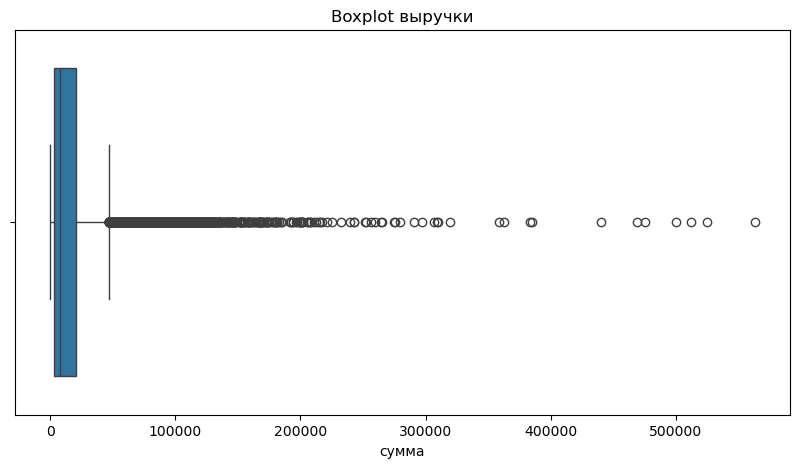

In [27]:
# График размаха (boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(x=all_check_result['сумма'])
plt.title('Boxplot выручки')
plt.show()

In [28]:
#изучаем выбросы минимальные
lower_bound = all_check_result['сумма'].quantile(0.01)
lower_bound

np.float64(100.0)

In [29]:
# Фильтрация данных по 99-му процентилю
all_check_result_25 = all_check_result[(all_check_result['сумма'] > lower_bound)].copy()

# Удаляем строки с пустыми значениями в столбце "Файлы"
all_check_result_25 = all_check_result_25.dropna(subset=['статус'])

In [30]:
#Добавляем день недели
all_check_result_25["дата"] = pd.to_datetime(all_check_result_25["дата"], dayfirst=True, errors='coerce' )
all_check_result_25.insert(1, "день_недели", (all_check_result_25['дата'].dt.day_name()))

In [31]:
#Изучаем дубликаты
duplicates = all_check_result_25[all_check_result_25.duplicated(subset=['дата', 'номер', 'сумма'])].sort_values(by='номер')
print(len(duplicates))
duplicates

0


,дата,день_недели,время,номер,сумма,сумма_скидки,операция,статус,магазин,продавец,заказ_покупателя


In [32]:
#Удаляем дубликаты
all_check_result_25 = all_check_result_25.drop_duplicates(subset=['дата', 'номер', 'сумма'])

In [33]:
#Удаляем не нужные столбцы
del all_check_result_25["статус"]
del all_check_result_25['операция']

In [34]:
#Добавляем новый столбец с примененой скидокй %.
all_check_result_25['скидка'] = (all_check_result_25['сумма_скидки'] / all_check_result_25['сумма']*100).round(2)

In [35]:
#изучаем значения в столбце скидка
all_check_result_25['скидка'].describe()

count   17841.00
mean       12.04
std        41.95
min         0.00
25%         0.00
50%         5.02
75%        19.20
max      3033.78
Name: скидка, dtype: float64

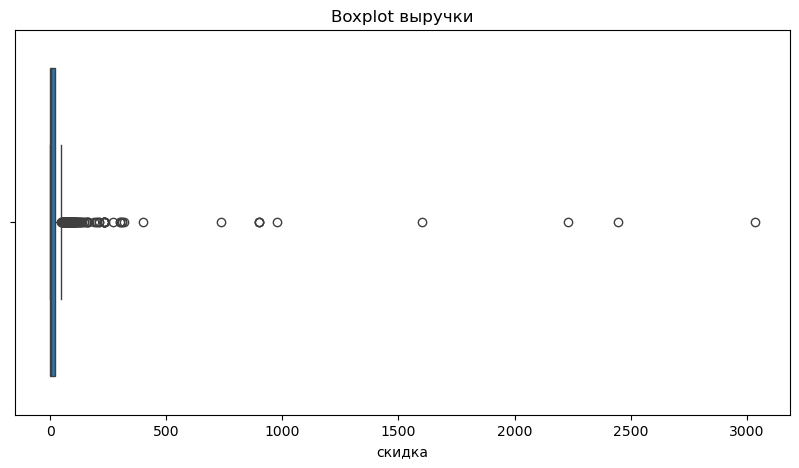

In [36]:
# График размаха (boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(x=all_check_result_25['скидка'])
plt.title('Boxplot выручки')
plt.show()

In [37]:
#сохраняем удаляемые строки для проверки
all_check_result_fake_sell_2 = all_check_result_25[(all_check_result_25['скидка']> 35)]
#Фильтруем датафрейм, убирая фиктивные скидки. Для обычных случаев такие скидки запрещены. 
#Они прмиеняются или для продажи просрочки, или для лояльности в спорных решениях, или покупка сотрудником
all_check_result_25 = all_check_result_25[( all_check_result_25['скидка']<= 35)]

In [38]:
all_check_result_25['скидка'].describe()

count   17286.00
mean        9.42
std        10.50
min         0.00
25%         0.00
50%         4.17
75%        17.66
max        34.92
Name: скидка, dtype: float64

In [39]:
#Считаем число строк
number_od_rows_all_check_result_25 = len(all_check_result_25['дата'])

number_del = number_od_rows_all_check - number_od_rows_all_check_result_25
perc_del = (number_od_rows_all_check - number_od_rows_all_check_result_25) /number_od_rows_all_check*100
print(f'число удаленных строк: {number_del}')
print(f'доля удаленных строк: {perc_del}')

число удаленных строк: 479209
доля удаленных строк: 96.51839394153012


In [40]:
number_od_rows_all_check

496495

## Вывод по подготовке данных:

- оставшиеся кол-во строк 464394 
- убраны или заменены все пропуски. Пропуски были типа MAR (Missing at Random.)
- Удалены пропуски в столбце "статус". MAR (Missing at Random.), чеки не проведенные
- Удалены чеки со статусами: "отложенный", "возврат".
- удалены чеки с операциями: "возврат"
- Удалены дубликаты: 1 строка, не повлияет на результат
- Удалены выбросы. 1% от общего числа данных. чеки меньше 25 рублей.
- удаленны 32100 строки
- удалены 6,46% строк данных, которые не содержат информацию о проведенных чеках, или содержат выбросы (слишком маленькие чеки)
- добавлен столбец дата
- добавлен столбец время
- добавлен столбец с днем неделей.
- удален старый столбец с датой и временем
- Удалены 6447 продаж со скидками более 35%

- Столбец "продажа", 'статус' - более не актуален. оставляем только продажу
- Столбец "магазин" содержит 134 магазина
- Столбец "продавец"  содержит 277 ПК

## Сформировать признак по размеру чека.

In [41]:
# добавить столбцы с булевым значением по сегментации
all_check_result_25['bool_чек_больше_20000'] = all_check_result_25['сумма'] >= 20000
all_check_result_25['bool_чек_меньше_5000'] = all_check_result_25['сумма'] < 5000
all_check_result_25['bool_чек_больше_40000'] = all_check_result_25['сумма'] >= 40000

In [45]:
#Добавляем колонки для чеков свыше 20 тысяч
all_check_result_25['сумма_20'] = np.where(all_check_result_25['bool_чек_больше_20000'], all_check_result_25['сумма'], 0)
all_check_result_25['скидка_20'] = np.where(all_check_result_25['bool_чек_больше_20000'], all_check_result_25['сумма_скидки'], 0)
#Добавляем колонки для чеков свыше 40 тысяч
all_check_result_25['сумма_40'] = np.where(all_check_result_25['bool_чек_больше_40000'], all_check_result_25['сумма'], 0)
all_check_result_25['скидка_40'] = np.where(all_check_result_25['bool_чек_больше_40000'], all_check_result_25['сумма_скидки'], 0)

## Агрегировать данные по продавцам

In [47]:
#группируем чеки по продавцам
pk_all_check = all_check_result_25.groupby('продавец', as_index=False).agg(
    продажи_руб = ('сумма', 'sum')
    , скидки_руб = ('сумма_скидки', 'sum')
    , чеки_штуки = ('номер', 'count')
    , чеки_меньше_5000_шт = ('bool_чек_меньше_5000', 'sum')
    , чеки_больше_20тыс_шт = ('bool_чек_больше_20000', 'sum')
    , чеки_больше_40тыс_шт = ('bool_чек_больше_40000', 'sum')
    , чеки_больше_20тыс_руб = ('сумма_20', 'sum')
    , скидки_на_чеки_больше_20тыс_руб = ('скидка_20', 'sum')
    , чеки_больше_40тыс_руб = ('сумма_40', 'sum')
    , скидки_на_чеки_больше_40тыс_руб = ('скидка_40', 'sum'))

#рассчитываем доли
pk_all_check['скидка_%'] = pk_all_check['скидки_руб'] / pk_all_check['продажи_руб'] * 100
pk_all_check['средний_чек'] = pk_all_check['продажи_руб'] / pk_all_check['чеки_штуки'] 
pk_all_check['скидка_на_чеки_свыше_20тыс_%'] = pk_all_check['скидки_на_чеки_больше_20тыс_руб'] / pk_all_check['чеки_больше_20тыс_руб'] * 100
pk_all_check['скидка_на_чеки_свыше_49тыс_%'] = pk_all_check['скидки_на_чеки_больше_40тыс_руб'] / pk_all_check['чеки_больше_40тыс_руб'] * 100

#Фильтрация. Эмпирическим путем. оставляем продавцов с количеством чеков больше 200
#Пеириод данных 1 год, это меньше 16,6 чеков в месяц.
pk_all_check = pk_all_check[pk_all_check['чеки_штуки'] > 200]

## Квантильный биннинг по проходимости

In [48]:
# квантильный биннинг
#  не требуется больших навыков продавца, чтобы продать товар менее 5 тыс руб (именно для данной товарной группы)
# Именно по нему будем мерить проходимость
quantiles = pk_all_check['чеки_меньше_5000_шт'].quantile([0.2, 0.4, 0.6, 0.8])

# Создание категорий
def categorize_discount(x, q1, q2, q3, q4):
    if x <= q1:
        return 'низкая_проходимость'
    elif x <= q2:
        return 'Средняя_проходимость'
    elif x <= q3:
        return 'хорошая_проходимость'
    elif x <= q4:
        return 'высокая_проходимость'    
    else:
        return 'Очень_высокая_проходимость'


# Применение функции к датафрейму
pk_all_check['проходимость'] = pk_all_check['чеки_меньше_5000_шт'].apply(
    lambda x: categorize_discount(
        x, 
        quantiles[0.2], 
        quantiles[0.4], 
        quantiles[0.6],
        quantiles[0.8]
    )
)

## Квантильный биннинг по скидкам применяемым скидкам

In [50]:
# Расчет квартилей
quantiles = pk_all_check['скидки_руб'].quantile([0.2, 0.4, 0.6, 0.8])

# Создание категорий
def categorize_discount(x, q1, q2, q3, q4):
    if x <= q1:
        return 'Низкие скидки (Q1)'
    elif x <= q2:
        return 'Средние скидки (Q2)'
    elif x <= q3:
        return 'выше среднего скидки (Q3)'
    elif x <= q4:
        return 'Высокие скидки (Q4)'
    else:
        return 'Очень высокие скидки (Q5)'

# Применение функции к датафрейму
pk_all_check['категория_скидок'] = pk_all_check['скидки_руб'].apply(
    lambda x: categorize_discount(
        x, 
        quantiles[0.2], 
        quantiles[0.4], 
        quantiles[0.6],
        quantiles[0.8]
    )
)

In [52]:
# 1. Берем сегменты продавцов
seller_segments = pk_all_check[
    ['продавец', 'проходимость', 'категория_скидок']
].copy()

# 2. Добавляем сегменты к каждому чеку
check_data = all_check_result_25.merge(
    seller_segments,
    on='продавец',
    how='inner'
)

# 3. Проверяем, все ли чеки получили сегменты
check_data[['проходимость', 'категория_скидок']].isna().sum()

проходимость        0
категория_скидок    0
dtype: int64

In [53]:
check_data.head(2)

,дата,день_недели,время,номер,сумма,сумма_скидки,магазин,продавец,заказ_покупателя,скидка,bool_чек_больше_20000,bool_чек_меньше_5000,bool_чек_больше_40000,сумма_20,скидка_20,сумма_40,скидка_40,проходимость,категория_скидок
0,2025-04-08,Tuesday,18:55:08,Номер_13593,105.00,0.00,Продавец_48,Продавец_56,Заказ_210,0.00,False,True,False,0.00,0.00,0.00,0.00,Очень_высокая_проходимость,Низкие скидки (Q1)
1,2025-06-30,Monday,13:35:18,Номер_15956,119.00,21.00,Продавец_112,Продавец_162,Заказ_217,17.65,False,True,False,0.00,0.00,0.00,0.00,Очень_высокая_проходимость,Очень высокие скидки (Q5)


In [54]:
pk_all_check.head(2)

,продавец,продажи_руб,скидки_руб,чеки_штуки,чеки_меньше_5000_шт,чеки_больше_20тыс_шт,чеки_больше_40тыс_шт,чеки_больше_20тыс_руб,скидки_на_чеки_больше_20тыс_руб,чеки_больше_40тыс_руб,скидки_на_чеки_больше_40тыс_руб,скидка_%,средний_чек,скидка_на_чеки_свыше_20тыс_%,скидка_на_чеки_свыше_49тыс_%,проходимость,категория_скидок
54,Продавец_15,3835956.00,632036.00,230,73,65,20,2620970.00,470581.00,1364516.00,248904.00,16.48,16678.07,17.95,18.24,низкая_проходимость,Очень высокие скидки (Q5)
68,Продавец_162,5445362.20,894822.00,414,182,77,30,3389066.00,593315.00,2112292.00,370691.00,16.43,13153.05,17.51,17.55,Очень_высокая_проходимость,Очень высокие скидки (Q5)


In [58]:
#сохраняем
check_data.to_csv(DATA_DIR / 'check_data.csv',
    index=False,
    encoding='utf-8-sig')

pk_all_check.to_csv(DATA_DIR / 'pk_all_check.csv',
    index=False,
    encoding='utf-8-sig')

# Общий Вывод:
- данные очищены:
    - дубликатов
    - технической информации (возвратов, отложенных чеков)
    - чеков с анамальными скидками более 35%
    - мелкими чеками пакеты,списание просрочки менее 100 рублей (товары с такой стоимостью отсутствуют в номеклатуре)
- добавлены категории по уровню скидок и проходимости
- данные агрегированы на уровень продавца
